In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Modules - 1, 2, 3, 4, 5

In [2]:
def calculate_lj_properties(r_sq, r_cutoff_sq):
    """
    Calculates reduced potential energy and force magnitude for a pair of atoms.
    Implements the shifted Lennard-Jones potential: phi(r) - phi(rc).
    Returns (potE, force/r).
    """
    inv_rc2 = 1.0 / r_cutoff_sq
    inv_rc6 = inv_rc2**3
    inv_rc12 = inv_rc6**2
    phi_cut = 4 * (inv_rc12 - inv_rc6)

    inv_r2 = 1.0 / r_sq
    inv_r6 = inv_r2**3
    inv_r12 = inv_r6**2

    phi = 4 * (inv_r12 - inv_r6)

    force_by_r = 48 * inv_r2 * (inv_r12 - 0.5 * inv_r6)
    force_by_rc = 48 * inv_rc2 * (inv_rc12 - 0.5 * inv_rc6)
    force_by_r = force_by_r - force_by_rc
    potE = phi - phi_cut + 0.5 * force_by_rc * (r_sq - r_cutoff_sq)

    return potE, force_by_r


def generate_fcc_lattice(n_cells, rho_star):
    """
    Generates an FCC lattice of atoms.
    Returns (positions array of shape (N,3), box length L).
    N = 4 * n_cells^3.
    """
    L = (4 * n_cells**3 / rho_star) ** (1 / 3)
    a = L / n_cells
    b1 = np.array([0, 0, 0])
    b2 = np.array([a / 2, a / 2, 0])
    b3 = np.array([a / 2, 0, a / 2])
    b4 = np.array([0, a / 2, a / 2])
    positions = []
    for i in range(n_cells):
        for j in range(n_cells):
            for k in range(n_cells):
                cell_origin = np.array([i, j, k]) * (L / n_cells)
                positions.append(cell_origin + b1)
                positions.append(cell_origin + b2)
                positions.append(cell_origin + b3)
                positions.append(cell_origin + b4)
    return np.array(positions), L


def apply_minimum_image(pos_i, pos_j, L):
    """
    Calculates the shortest distance vector between two atoms using
    the minimum image convention. dx, dy, dz are kept in [-L/2, L/2].
    """
    dr = pos_j - pos_i
    dr -= L * np.round(dr / L)
    return dr


def calculate_total_force(pos, box_length, r_cutoff_sq):
    """Returns (total_pe, forces array of shape (N,3))."""
    N = len(pos)
    forces = np.zeros((N, 3))
    dr = apply_minimum_image(pos[:, np.newaxis, :], pos[np.newaxis, :, :], box_length)
    r_sq = np.sum(dr**2, axis=2)
    r_sq = np.triu(r_sq, k=1)
    mask = (r_sq < r_cutoff_sq) & (r_sq > 0)
    pot, force_by_r = np.zeros_like(r_sq), np.zeros_like(r_sq)
    pot[mask], force_by_r[mask] = calculate_lj_properties(r_sq[mask], r_cutoff_sq)
    f_mat = force_by_r[:, :, np.newaxis] * dr
    forces += np.sum(f_mat, axis=0)
    forces -= np.sum(f_mat, axis=1)
    total_pe = np.sum(pot)
    return total_pe, forces


def calculate_kinetic_energy(vel):
    """K* = 0.5 * sum(v²)  [m* = 1 in reduced units]"""
    return 0.5 * np.sum(vel**2)


def update_neighbor_list(pos, L, r_skin_sq):
    """
    Builds a list of atom pairs (i, j) within the skin radius.
    Uses the Minimum Image Convention. Fully vectorized.
    """
    dr = apply_minimum_image(pos[:, np.newaxis, :], pos[np.newaxis, :, :], L)
    r_sq = np.sum(dr**2, axis=2)
    i_idx, j_idx = np.where(np.triu(r_sq < r_skin_sq, k=1))
    return np.stack([i_idx, j_idx], axis=1)


def calculate_forces_optimized(pos, neighbor_pairs, L, r_cutoff_sq):
    """
    Calculates total forces using only the pairs in the neighbor list.
    Returns (total_pe, forces array of shape (N,3)).
    """
    N = len(pos)
    forces = np.zeros((N, 3))
    total_pe = 0.0
    if len(neighbor_pairs) == 0:
        return total_pe, forces

    i_idx = neighbor_pairs[:, 0]
    j_idx = neighbor_pairs[:, 1]

    dr = apply_minimum_image(pos[i_idx], pos[j_idx], L)
    r_sq = np.sum(dr**2, axis=1)

    mask = r_sq < r_cutoff_sq
    pot, force_by_r = calculate_lj_properties(r_sq[mask], r_cutoff_sq)

    f_vec = force_by_r[:, np.newaxis] * dr[mask]
    np.add.at(forces, i_idx[mask], -f_vec)
    np.add.at(forces, j_idx[mask],  f_vec)
    total_pe = np.sum(pot)
    return total_pe, forces


def velocity_verlet_step_opt(pos, vel, force, dt, box_length, r_cutoff_sq, neighbour_list):
    """
    Velocity Verlet step using the optimized neighbor-list force calculation.
    Returns (pos_new, vel_new, pe_new, force_new).
    """
    pos_new = pos + vel * dt + 0.5 * force * dt**2
    pos_new = pos_new % box_length
    vel_mid = vel + 0.5 * force * dt
    pe_new, force_new = calculate_forces_optimized(pos_new, neighbour_list, box_length, r_cutoff_sq)
    vel_new = vel_mid + 0.5 * force_new * dt
    return pos_new, vel_new, pe_new, force_new

def initialize_velocities(N, T_target):
    """
    Assigns initial velocities from a Maxwell-Boltzmann distribution.
    Generates a (N, 3) array with std_dev = sqrt(T_target),
    then removes net momentum so the center-of-mass is stationary.
    """
    sigma = np.sqrt(T_target)
    vel = np.random.normal(loc=0.0, scale=sigma, size=(N, 3))
    vel -= vel.mean(axis=0)  
    return vel

def rescale_velocities ( vel , T_target ) :

    """
    Scales velocities to match the target temperature .
    """
    # 1. Calculate current T_inst = (sum v^2) / 3N
    # 2. Scale factor lambda = sqrt ( T_target / T_inst )
    # 3. vel = vel * lambda
    T_inst = np.sum(vel**2) / (3 * len(vel))
    lambda_factor = np.sqrt(T_target / T_inst)
    vel *= lambda_factor
    return vel

## Module - 6

In [3]:
# --- Module 6 Coding Task : Final Analysis ---

def calculate_rdf ( pos , box_length , dr , r_max ):
    """
    Calculates the Radial Distribution Function g(r).
    TASK :
    1. Loop through all pairs and calculate distance r using MIC .
    2. Sort distances into a histogram with bin width dr.
    3. Normalize by the volume of the spherical shells and density .
    """
    N = len(pos)

    n_bins = int(np.round(r_max / dr))
    g_hist = np.zeros(n_bins)

    dr_vec = apply_minimum_image(pos[:, np.newaxis, :], pos[np.newaxis, :, :], box_length)
    r_sq = np.sum(dr_vec**2, axis=2)
    r_dist = np.sqrt(r_sq[np.triu_indices(N, k=1)])
    valid_dist = r_dist[r_dist < r_max]

    k = (valid_dist / dr).astype(int)

    cnt = np.bincount(k, minlength=n_bins)
    g_hist += cnt

    r_centers = (np.arange(n_bins) + 0.5) * dr
    shell_vol = 4 * np.pi * (r_centers**2) * dr

    g_r = (2.0 * g_hist * ((box_length)**3)) / (N * N * shell_vol)
    
    return r_centers, g_r

### **Module 6 Test: Observing Melting through the Radial Distribution Function**  
This simulation gradually heats atoms to observe the phase transition from a highly structured crystal to a disordered liquid. 

1. **Equilibration (1,000 steps):** A thermostat adjusts the atoms' velocities until the system stabilizes at the target temperature.
2. **Production (1,000 steps):** The simulation runs naturally. We calculate $g(r)$ every 10 steps.

By averaging these periodic snapshots, we get a smooth $g(r)$ curve that clearly shows the sharp peaks of a solid lattice flattening out into the disordered state of a liquid.

Running simulation for T* = 0.2...
Running simulation for T* = 0.4...
Running simulation for T* = 0.6...
Running simulation for T* = 0.8...
Running simulation for T* = 1.0...


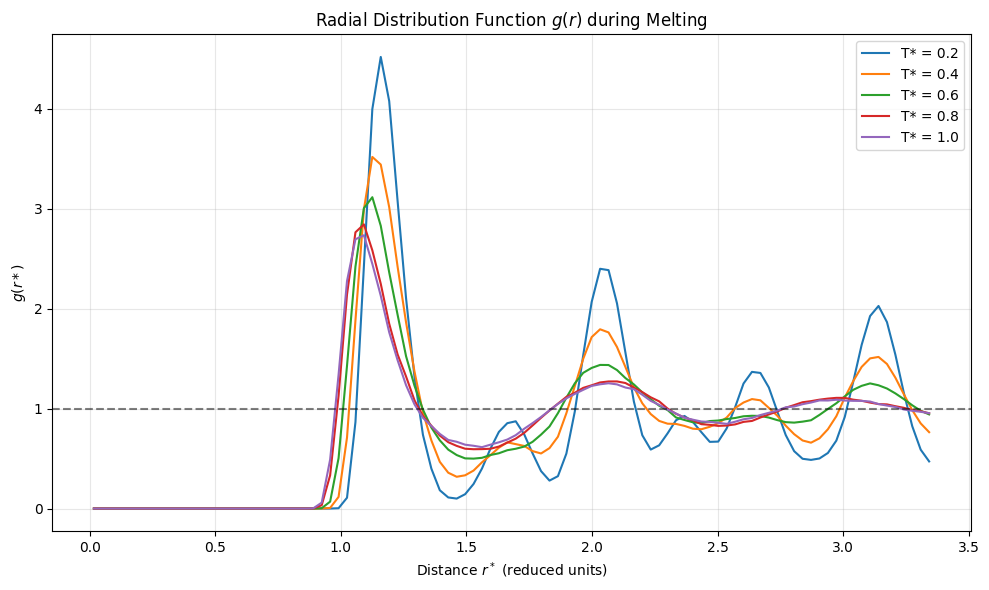

In [4]:
# Melting
n_cells     = 4
rho_star    = 0.8442
T_target    = 1.0
dt          = 0.005
total_steps = 2000
r_cutoff    = 2.5
r_cutoff_sq = r_cutoff ** 2
r_skin      = 3.2
r_skin_sq   = r_skin ** 2

pos, L = generate_fcc_lattice(n_cells, rho_star)
N      = len(pos)
vel    = initialize_velocities(N, T_target)

neighbour_list   = update_neighbor_list(pos, L, r_skin_sq)
pe, force        = calculate_forces_optimized(pos, neighbour_list, L, r_cutoff_sq)
pos_ref          = pos.copy()
rebuild_threshold_sq = 0.25 * (r_skin - r_cutoff) ** 2
temperatures = [0.2, 0.4, 0.6, 0.8, 1.0]
equilibration_steps = 1000
production_steps = 1000
dt = 0.005
r_max = L / 2.0  # Max distance is half the box length
dr = r_max / 100.0  # 100 bins

plt.figure(figsize=(10, 6))

for T_target in temperatures:
    print(f"Running simulation for T* = {T_target}...")
    
    # Re-initialize for each temperature run to simulate the stepping process 
    # (or you can carry the positions over to naturally melt it, but scaling velocities is safer here)
    vel = initialize_velocities(N, T_target)
    neighbour_list = update_neighbor_list(pos, L, r_skin_sq)
    pe, force = calculate_forces_optimized(pos, neighbour_list, L, r_cutoff_sq)
    
    # 1. Equilibration Phase
    for step in range(equilibration_steps):
        pos, vel, pe, force = velocity_verlet_step_opt(pos, vel, force, dt, L, r_cutoff_sq, neighbour_list)
        
        # Update neighbor list if atoms moved too far
        disp_sq = np.sum((pos - pos_ref)**2, axis=1)
        if np.any(disp_sq > rebuild_threshold_sq):
            neighbour_list = update_neighbor_list(pos, L, r_skin_sq)
            pos_ref = pos.copy()
            
        # Velocity rescaling thermostat
        if step % 10 == 0:
            vel = rescale_velocities(vel, T_target)

    # 2. Production Phase (Collect g(r) data)
    g_r_accumulated = np.zeros(int(r_max/dr))
    collection_count = 0
    
    for step in range(production_steps):
        pos, vel, pe, force = velocity_verlet_step_opt(pos, vel, force, dt, L, r_cutoff_sq, neighbour_list)
        
        disp_sq = np.sum((pos - pos_ref)**2, axis=1)
        if np.any(disp_sq > rebuild_threshold_sq):
            neighbour_list = update_neighbor_list(pos, L, r_skin_sq)
            pos_ref = pos.copy()
            
        # Collect g(r) periodically to avoid highly correlated data (e.g., every 10 steps)
        if step % 10 == 0:
            r_centers, g_r_current = calculate_rdf(pos, L, dr, r_max)
            g_r_accumulated += g_r_current
            collection_count += 1
            
    # Average the collected g(r) data
    g_r_avg = g_r_accumulated / collection_count
    
    # Plot this temperature's g(r)
    plt.plot(r_centers, g_r_avg, label=f'T* = {T_target}')

# Finalize the plot
plt.title('Radial Distribution Function $g(r)$ during Melting')
plt.xlabel('Distance $r^*$ (reduced units)')
plt.ylabel('$g(r*)$')
plt.axhline(1.0, color='black', linestyle='--', alpha=0.5) # Asymptote reference line
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **Module - 6 Krypton MD Simulation: Solid vs. Liquid Phase**
This code runs a Molecular Dynamics simulation of Krypton at two different temperatures ($T^* = 0.2$ and $T^* = 1.0$) to compare their atomic structures. 

The simulation executes the following steps for each temperature:
1. **Setup:** Initializes a 500-atom FCC lattice with parameters specific to Krypton.
2. **Equilibration (2,000 steps):** Applies a velocity-rescaling thermostat every 10 steps to bring the system to the target temperature.
3. **Production (2,000 steps):** The thermostat turns off, allowing the system to evolve naturally using velocity verlet and optimized neighbor lists.
4. **Analysis:** Calculates the Radial Distribution Function $g(r)$ on the final frame, converting distances into Ångströms (Å). The resulting plots highlight the sharp peaks of a solid versus the broad, flattened curves of a melted liquid.

Starting Heating Process...
Running simulation for T* = 0.10...
Running simulation for T* = 0.20...
Running simulation for T* = 0.30...
Running simulation for T* = 0.40...
Running simulation for T* = 0.50...
Running simulation for T* = 0.60...
Running simulation for T* = 0.70...
Running simulation for T* = 0.80...
Running simulation for T* = 0.90...
Running simulation for T* = 1.00...
Running simulation for T* = 1.10...
Running simulation for T* = 1.20...
Running simulation for T* = 1.30...
Running simulation for T* = 1.40...
Running simulation for T* = 1.50...


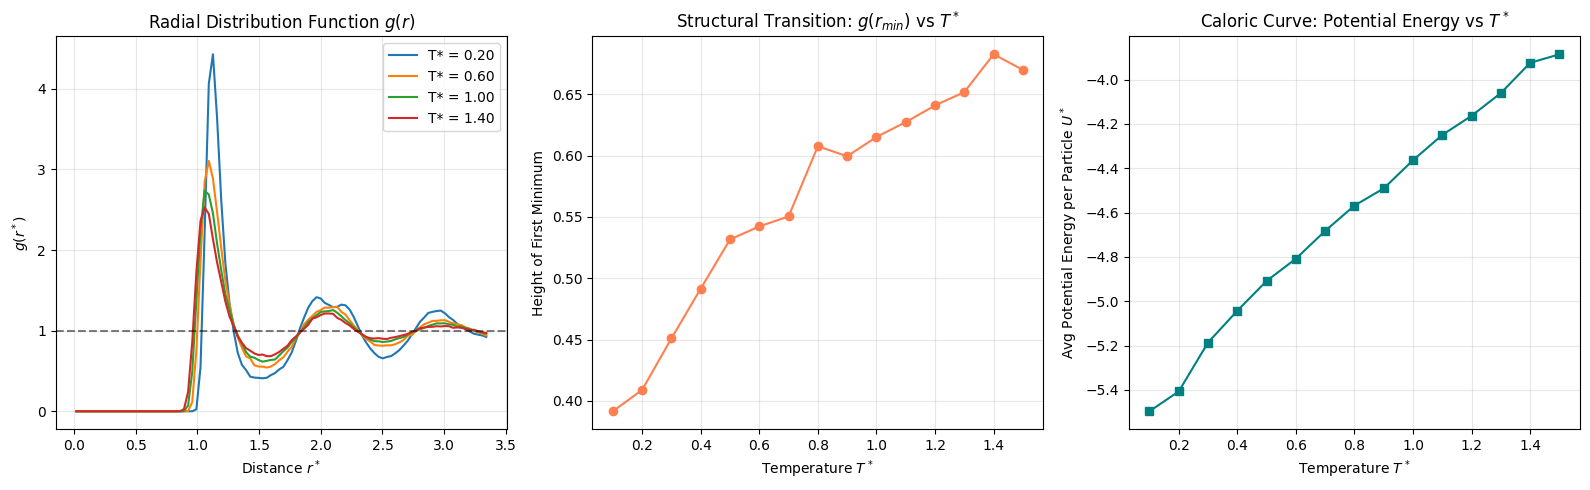

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ... [Keep your initial lattice, parameter setup, and function definitions here] ...

# Use a finer temperature gradient to accurately spot the phase transition
temperatures = np.linspace(0.1, 1.5, 15) 
equilibration_steps = 1000
production_steps = 1000

# Arrays to store data for our melting point analysis
avg_pe_vs_T = []
g_min_vs_T = []
r_centers_list = []
g_r_list = []

print("Starting Heating Process...")

for T_target in temperatures:
    print(f"Running simulation for T* = {T_target:.2f}...")
    
    vel = initialize_velocities(N, T_target)
    neighbour_list = update_neighbor_list(pos, L, r_skin_sq)
    pe, force = calculate_forces_optimized(pos, neighbour_list, L, r_cutoff_sq)
    
    # 1. Equilibration Phase
    for step in range(equilibration_steps):
        pos, vel, pe, force = velocity_verlet_step_opt(pos, vel, force, dt, L, r_cutoff_sq, neighbour_list)
        
        disp_sq = np.sum((pos - pos_ref)**2, axis=1)
        if np.any(disp_sq > rebuild_threshold_sq):
            neighbour_list = update_neighbor_list(pos, L, r_skin_sq)
            pos_ref = pos.copy()
            
        if step % 10 == 0:
            vel = rescale_velocities(vel, T_target)

    # 2. Production Phase
    g_r_accumulated = np.zeros(int(r_max/dr))
    collection_count = 0
    pe_history = [] # Track potential energy for the caloric curve
    
    for step in range(production_steps):
        pos, vel, pe, force = velocity_verlet_step_opt(pos, vel, force, dt, L, r_cutoff_sq, neighbour_list)
        pe_history.append(pe) # Collect PE
        
        disp_sq = np.sum((pos - pos_ref)**2, axis=1)
        if np.any(disp_sq > rebuild_threshold_sq):
            neighbour_list = update_neighbor_list(pos, L, r_skin_sq)
            pos_ref = pos.copy()
            
        if step % 10 == 0:
            r_centers, g_r_current = calculate_rdf(pos, L, dr, r_max)
            g_r_accumulated += g_r_current
            collection_count += 1
            
    # Process Production Data
    g_r_avg = g_r_accumulated / collection_count
    g_r_list.append(g_r_avg)
    r_centers_list = r_centers # x-axis is identical for all runs
    
    # Calculate Average Potential Energy (normalized per particle)
    avg_pe_vs_T.append(np.mean(pe_history) / N)
    
    # Isolate the first minimum in g(r)
    # The 1st LJ peak is usually around r* = 1.12. The minimum occurs between 1.2 and 1.8.
    search_indices = np.where((r_centers > 1.2) & (r_centers < 1.8))[0]
    if len(search_indices) > 0:
        first_min = np.min(g_r_avg[search_indices])
    else:
        first_min = 0
    g_min_vs_T.append(first_min)


# --- PLOTTING THE RESULTS ---
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Standard g(r) overlapping (Displaying a subset to avoid clutter)
plot_indices = [1, 5, 9, 13] 
for idx in plot_indices:
    axs[0].plot(r_centers_list, g_r_list[idx], label=f'T* = {temperatures[idx]:.2f}')
axs[0].set_title('Radial Distribution Function $g(r)$')
axs[0].set_xlabel('Distance $r^*$')
axs[0].set_ylabel('$g(r^*)$')
axs[0].axhline(1.0, color='black', linestyle='--', alpha=0.5)
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Plot 2: Structural Metric - First Minimum of g(r)
axs[1].plot(temperatures, g_min_vs_T, marker='o', color='coral', linestyle='-')
axs[1].set_title('Structural Transition: $g(r_{min})$ vs $T^*$')
axs[1].set_xlabel('Temperature $T^*$')
axs[1].set_ylabel('Height of First Minimum')
axs[1].grid(True, alpha=0.3)

# Plot 3: Thermodynamic Metric - Caloric Curve (Potential Energy)
axs[2].plot(temperatures, avg_pe_vs_T, marker='s', color='teal', linestyle='-')
axs[2].set_title('Caloric Curve: Potential Energy vs $T^*$')
axs[2].set_xlabel('Temperature $T^*$')
axs[2].set_ylabel('Avg Potential Energy per Particle $U^*$')
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **Module - 6: Krypton Simulation at 0 K**
This code models a perfectly frozen Krypton crystal at absolute zero. 

* **The Simulation:** Tracks 500 atoms locked in a crystal lattice with zero thermal vibration.
* **The Output:** Plots the Radial Distribution Function $g(r)$. Because the atoms don't move, the graph displays sharp, narrow spikes instead of smooth waves.

Running for Krypton at T* = 0.0  (≈ 0 K)...


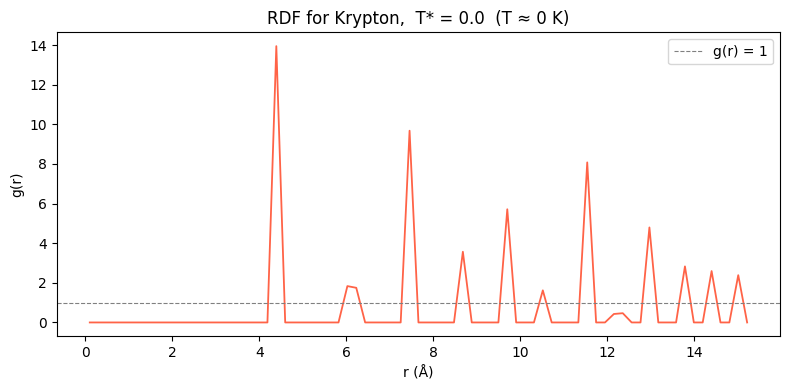

  At 0 K, expect broad peaks decaying to 1.0 (liquid)


In [6]:
eV_to_K        = 11604.52
eps_over_kB_Kr = 0.0140 * eV_to_K    # 162.46 K
sigma_Kr_A     = 3.65                # Angstroms
T_melting_K = 115.79

n_cells     = 5   
rho_star    = 0.8442
dt          = 0.005
total_steps = 4000
equil_steps = 2000
r_cutoff    = 2.5
r_cutoff_sq = r_cutoff**2
r_skin      = 3.2
r_skin_sq   = r_skin**2
rebuild_threshold_sq = 0.25 * (r_skin - r_cutoff)**2

for T_target in [0.0]:
    T_real_K = T_target * T_melting_K
    print(f"Running for Krypton at T* = {T_target}  (≈ {T_real_K:.0f} K)...")

    pos, L    = generate_fcc_lattice(n_cells, rho_star)
    N         = len(pos)
    pos_ref   = pos.copy()
    vel       = initialize_velocities(N, T_target)
    nb        = update_neighbor_list(pos, L, r_skin_sq)
    pe, force = calculate_forces_optimized(pos, nb, L, r_cutoff_sq)

    # Run loop 
    for step in range(total_steps):
        pos, vel, pe, force = velocity_verlet_step_opt(
            pos, vel, force, dt, L, r_cutoff_sq, nb)

        disp_sq = np.sum((pos - pos_ref)**2, axis=1)
        if np.any(disp_sq > rebuild_threshold_sq):
            nb      = update_neighbor_list(pos, L, r_skin_sq)
            pos_ref = pos.copy()

        if step < equil_steps and step % 10 == 0:
            vel = rescale_velocities(vel, T_target)

    r_max  = L / 2.0
    n_bins = 75
    dr     = r_max / n_bins

    r_centers, g_r = calculate_rdf(pos, L, dr, r_max)
    r_angstrom = r_centers * sigma_Kr_A

    plt.figure(figsize=(8, 4))
    plt.plot(r_angstrom, g_r, linewidth=1.3,
             color='steelblue' if T_target == 0.4 else 'tomato')
    plt.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='g(r) = 1')
    plt.xlabel('r (Å)')
    plt.ylabel('g(r)')
    plt.title(f'RDF for Krypton,  T* = {T_target}  (T ≈ {T_real_K:.0f} K)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    if T_target == 0.4:
        print(f"  At {T_real_K:.0f} K, expect sharp peaks (solid)")
    else:
        print(f"  At {T_real_K:.0f} K, expect broad peaks decaying to 1.0 (liquid)")

## For Report Purposes Only


Krypton  T* = 0.2  (T ≈ 32.5 K)
N = 500,  L* = 8.3980
Frames averaged : 100
First peak      : r* = 1.1477,  r = 4.189 Å,  g = 4.4509
Last 5 bin values (large r): [0.82738 0.8163  0.85181 1.01005 1.29831]
Mean of last 5 bins        : 0.96077  [expected ~1.0]


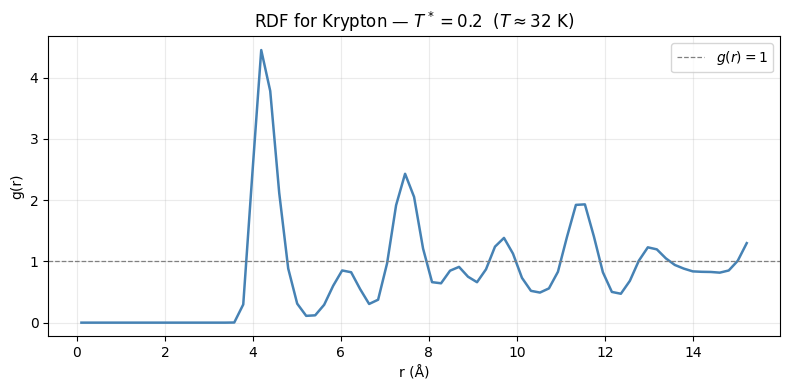

Saved: kr_gr_T02.pdf
State at 32 K: solid — expect sharp, distinct peaks

Krypton  T* = 1.0  (T ≈ 162.5 K)
N = 500,  L* = 8.3980
Frames averaged : 100
First peak      : r* = 1.0917,  r = 3.985 Å,  g = 2.6752
Last 5 bin values (large r): [1.03833 1.02497 1.01877 1.01084 0.99865]
Mean of last 5 bins        : 1.01831  [expected ~1.0]


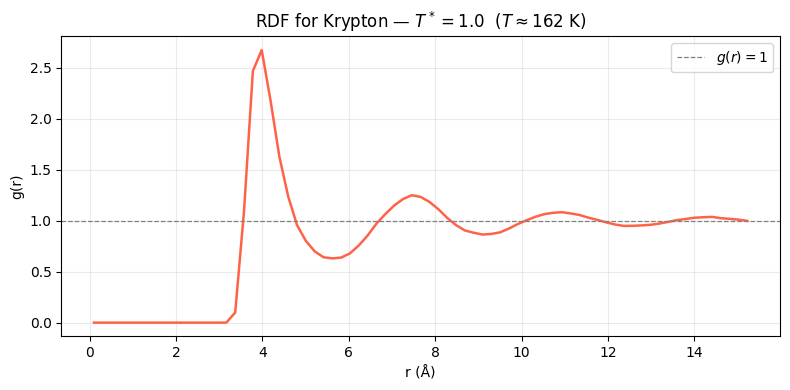

Saved: kr_gr_T10.pdf
State at 162 K: liquid — expect broad, decaying peaks


In [7]:
eV_to_K        = 11604.52
eps_over_kB_Kr = 0.0140 * eV_to_K    # 162.46 K
sigma_Kr_A     = 3.65                 # Angstroms

n_cells     = 5
rho_star    = 0.8442
dt          = 0.005
equil_steps = 2000
prod_steps  = 2000
total_steps = equil_steps + prod_steps
r_cutoff    = 2.5;  r_cutoff_sq = r_cutoff**2
r_skin      = 3.2;  r_skin_sq   = r_skin**2
rebuild_threshold_sq = 0.25 * (r_skin - r_cutoff)**2

# Pre-compute bin parameters (L is the same for all runs since rho* is fixed)
_, L   = generate_fcc_lattice(n_cells, rho_star)
r_max  = L / 2.0
n_bins = 75
dr     = r_max / n_bins
r_centers   = (np.arange(n_bins) + 0.5) * dr
r_angstrom  = r_centers * sigma_Kr_A

for T_target in [0.2, 1.0]:
    T_real_K = T_target * eps_over_kB_Kr
    print(f"\n{'='*55}")
    print(f"Krypton  T* = {T_target}  (T ≈ {T_real_K:.1f} K)")
    print(f"{'='*55}")

    # --- Fresh FCC start for each temperature ---
    pos, L    = generate_fcc_lattice(n_cells, rho_star)
    N         = len(pos)
    pos_ref   = pos.copy()
    vel       = initialize_velocities(N, T_target)
    nb        = update_neighbor_list(pos, L, r_skin_sq)
    pe, force = calculate_forces_optimized(pos, nb, L, r_cutoff_sq)

    g_acc           = np.zeros(n_bins)
    collection_count = 0

    for step in range(total_steps):
        pos, vel, pe, force = velocity_verlet_step_opt(
            pos, vel, force, dt, L, r_cutoff_sq, nb)

        disp_sq = np.sum((pos - pos_ref)**2, axis=1)
        if np.any(disp_sq > rebuild_threshold_sq):
            nb      = update_neighbor_list(pos, L, r_skin_sq)
            pos_ref = pos.copy()

        # Velocity rescaling during equilibration only
        if step < equil_steps and step % 10 == 0:
            vel = rescale_velocities(vel, T_target)

        # Collect g(r) every 20 steps during production
        if step >= equil_steps and step % 20 == 0:
            _, g_r_frame = calculate_rdf(pos, L, dr, r_max)
            g_acc           += g_r_frame
            collection_count += 1

    g_r_avg = g_acc / collection_count

    # --- Print numerical results ---
    pk_idx = np.argmax(g_r_avg)
    print(f"N = {N},  L* = {L:.4f}")
    print(f"Frames averaged : {collection_count}")
    print(f"First peak      : r* = {r_centers[pk_idx]:.4f},  "
          f"r = {r_angstrom[pk_idx]:.3f} Å,  g = {g_r_avg[pk_idx]:.4f}")
    print(f"Last 5 bin values (large r): {np.round(g_r_avg[-5:], 5)}")
    print(f"Mean of last 5 bins        : {g_r_avg[-5:].mean():.5f}  [expected ~1.0]")

    # --- Plot ---
    color     = 'steelblue' if T_target == 0.2 else 'tomato'
    filename  = f"kr_gr_T{'02' if T_target == 0.2 else '10'}.pdf"

    plt.figure(figsize=(8, 4))
    plt.plot(r_angstrom, g_r_avg, lw=1.8, color=color)
    plt.axhline(1.0, color='gray', ls='--', lw=0.9, label='$g(r) = 1$')
    plt.xlabel('r (Å)')
    plt.ylabel('g(r)')
    plt.title(f'RDF for Krypton — $T^* = {T_target}$  ($T \\approx {T_real_K:.0f}$ K)')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")

    state = "solid — expect sharp, distinct peaks" if T_target == 0.2 \
            else "liquid — expect broad, decaying peaks"
    print(f"State at {T_real_K:.0f} K: {state}")

N = 256,  L* = 6.7184,  r_max = L/2 = 3.3592
Equilibration: 800 steps | Production: 60 frames (every 10 steps = 600 steps)
Frames collected: 60  (target 60)
First peak : r* = 1.10,  g = 2.69
Mean of last 5 bins : 1.0059  (expected ≈ 1.0)


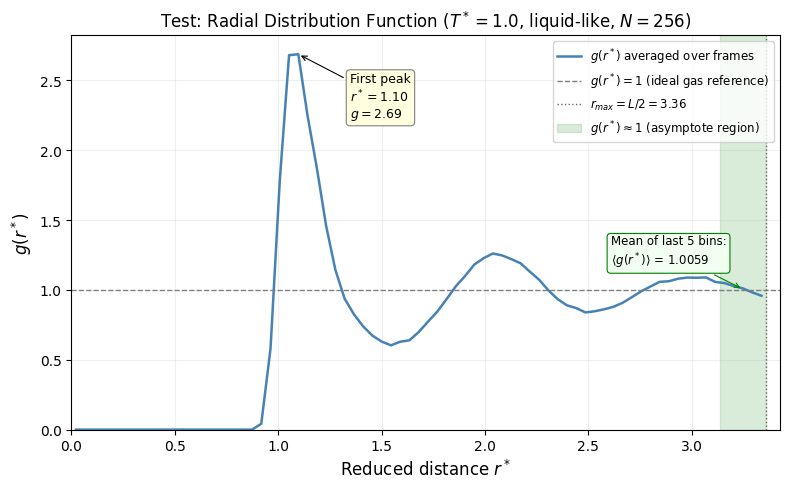

Saved: test_rdf_liquid_T1.pdf


In [8]:
"""
Test simulation: T* = 1.0, rho* = 0.8442, N = 256 (n_cells=4)
800 equilibration steps, g(r) averaged over 60 production frames.
Reproduces Figure 13 from the ESAM Project Report.
Paste this as a new cell AFTER your existing function definitions.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Parameters exactly as stated in Section 6.4 ──────────────────────────────
n_cells     = 4          # N = 4 * 4³ = 256
rho_star    = 0.8442
T_target    = 1.0
dt          = 0.005
equil_steps = 800        # 800 equilibration steps
n_frames    = 60         # average over 60 production frames
collect_every = 10       # collect every 20 steps → prod_steps = 60 * 10 = 600
prod_steps  = n_frames * collect_every
total_steps = equil_steps + prod_steps

r_cutoff    = 2.5;  r_cutoff_sq = r_cutoff**2
r_skin      = 3.2;  r_skin_sq   = r_skin**2
rebuild_threshold_sq = 0.25 * (r_skin - r_cutoff)**2

# ── Initialise ────────────────────────────────────────────────────────────────
pos, L   = generate_fcc_lattice(n_cells, rho_star)
N        = len(pos)                     # should be 256
pos_ref  = pos.copy()
vel      = initialize_velocities(N, T_target)
nb       = update_neighbor_list(pos, L, r_skin_sq)
pe, force = calculate_forces_optimized(pos, nb, L, r_cutoff_sq)

# ── Bin setup (reduced units — r*) ───────────────────────────────────────────
r_max  = L / 2.0          # r_max = L/2
n_bins = 75
dr     = r_max / n_bins
r_centers = (np.arange(n_bins) + 0.5) * dr   # bin centres in reduced units

g_acc           = np.zeros(n_bins)
collection_count = 0

print(f"N = {N},  L* = {L:.4f},  r_max = L/2 = {r_max:.4f}")
print(f"Equilibration: {equil_steps} steps | Production: {n_frames} frames "
      f"(every {collect_every} steps = {prod_steps} steps)")

# ── MD loop ──────────────────────────────────────────────────────────────────
for step in range(total_steps):
    pos, vel, pe, force = velocity_verlet_step_opt(
        pos, vel, force, dt, L, r_cutoff_sq, nb)

    # Rebuild neighbour list if needed
    disp_sq = np.sum((pos - pos_ref)**2, axis=1)
    if np.any(disp_sq > rebuild_threshold_sq):
        nb      = update_neighbor_list(pos, L, r_skin_sq)
        pos_ref = pos.copy()

    # Thermostat during equilibration only
    if step < equil_steps and step % 10 == 0:
        vel = rescale_velocities(vel, T_target)

    # Collect g(r) during production phase
    if step >= equil_steps and (step - equil_steps) % collect_every == 0:
        _, g_r_frame     = calculate_rdf(pos, L, dr, r_max)
        g_acc           += g_r_frame
        collection_count += 1

g_r_avg = g_acc / collection_count
print(f"Frames collected: {collection_count}  (target {n_frames})")

# ── Diagnostics ──────────────────────────────────────────────────────────────
pk_idx   = np.argmax(g_r_avg)
r_peak   = r_centers[pk_idx]
g_peak   = g_r_avg[pk_idx]
mean_tail = g_r_avg[-5:].mean()

print(f"First peak : r* = {r_peak:.2f},  g = {g_peak:.2f}")
print(f"Mean of last 5 bins : {mean_tail:.4f}  (expected ≈ 1.0)")

# ── Plot — matches Figure 13 exactly ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

# Main g(r) curve
ax.plot(r_centers, g_r_avg, color='steelblue', lw=1.8,
        label=r"$g(r^*)$ averaged over frames")

# g(r) = 1 reference
ax.axhline(1.0, color='gray', ls='--', lw=1.0,
           label=r"$g(r^*) = 1$ (ideal gas reference)")

# r_max = L/2 vertical dotted line
ax.axvline(r_max, color='dimgray', ls=':', lw=1.0,
           label=rf"$r_{{max}} = L/2 = {r_max:.2f}$")

# Shaded asymptote region (last 5 bins)
x_shade_start = r_centers[-5] - 0.5 * dr
ax.axvspan(x_shade_start, r_max, alpha=0.15, color='green',
           label=rf"$g(r^*) \approx 1$ (asymptote region)")

# Annotation: first peak
ax.annotate(
    f"First peak\n$r^* = {r_peak:.2f}$\n$g = {g_peak:.2f}$",
    xy=(r_peak, g_peak),
    xytext=(r_peak + 0.25, g_peak - 0.45),
    fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='gray', lw=0.8),
    arrowprops=dict(arrowstyle='->', color='black', lw=0.8)
)

# Annotation: mean of last 5 bins
ax.annotate(
    f"Mean of last 5 bins:\n" + r"$\langle g(r^*)\rangle$" + f" = {mean_tail:.4f}",
    xy=(r_centers[-3], mean_tail),
    xytext=(r_centers[-5] - 0.55, mean_tail + 0.18),
    fontsize=8.5,
    bbox=dict(boxstyle='round,pad=0.3', fc='honeydew', ec='green', lw=0.8),
    arrowprops=dict(arrowstyle='->', color='green', lw=0.8)
)

ax.set_xlabel(r"Reduced distance $r^*$", fontsize=12)
ax.set_ylabel(r"$g(r^*)$", fontsize=12)
ax.set_title(
    rf"Test: Radial Distribution Function ($T^* = {T_target}$, liquid-like, $N = {N}$)",
    fontsize=12
)
ax.set_xlim(0, r_max * 1.02)
ax.set_ylim(bottom=0)
ax.legend(fontsize=8.5, loc='upper right')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("m6_gr_test.pdf", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: test_rdf_liquid_T1.pdf")